<font size="+3"><strong>Predicting Price with Size</strong></font>

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In this project, you're working for a client who wants to create a model that can predict the price of apartments in the city of Buenos Aires — with a focus on apartments that cost less than $400,000 USD.

## **Prepare Data**

### **Import**

In the previous project, we cleaned our data files one-by-one. This isn't an issue when you're working with just three files, but imagine if you had several hundred! One way to automate the data importing and cleaning process is by writing a function. This will make sure that all our data undergoes the same process, and that our analysis is easily reproducible — something that's very important in science in general and data science in particular.

**Task 1:** Write a function named wrangle that takes a file path as an argument and returns a DataFrame.

In [2]:
def wrangle(filepath):
    df = pd.read_csv(filepath)
    return df

Now that we have a function written, let's test it out on one of the CSV files we'll use in this project.

**Task 2:** Use your wrangle function to create a DataFrame df from the CSV file `buenos-aires-real-estate-1.csv`.

In [3]:
df = wrangle("buenos-aires-real-estate-1.csv")
print("df shape:", df.shape)
df.head()

df shape: (8606, 16)


,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
0,sell,apartment,|Argentina|Capital Federal|Villa Crespo|,"-34.6047834183,-58.4586812499",180000.0,USD,2729232.0,180000.0,120.0,110.0,1500.000000,1636.363636,NaN,4.0,NaN,http://villa-crespo.properati.com.ar/12egq_ven...
1,sell,house,|Argentina|Bs.As. G.B.A. Zona Oeste|La Matanza...,NaN,250000.0,USD,3790600.0,250000.0,117.0,120.0,2136.752137,2083.333333,NaN,4.0,NaN,http://ramos-mejia.properati.com.ar/s7pd_venta...
2,sell,house,|Argentina|Bs.As. G.B.A. Zona Oeste|Morón|Cast...,"-34.6497002,-58.658073",410000.0,USD,6216584.0,410000.0,410.0,220.0,1000.000000,1863.636364,NaN,NaN,NaN,http://castelar-moron.properati.com.ar/11vgn_v...
3,sell,house,|Argentina|Bs.As. G.B.A. Zona Oeste|Tres de Fe...,"-34.5957086,-58.5669503",180000.0,USD,2729232.0,180000.0,200.0,135.0,900.000000,1333.333333,NaN,5.0,NaN,http://tres-de-febrero.properati.com.ar/7f7u_v...
4,sell,apartment,|Argentina|Capital Federal|Chacarita|,"-34.5846508988,-58.4546932614",129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...


For this project, we want to build a model for apartments in Buenos Aires proper ("Capital Federal") that cost less than $400,000. Looking at the first five rows of our DataFrame, we can already see that there are properties that fall outside those parameters. So our first cleaning task is to remove those observations from our dataset. Since we're using a function to import and clean our data, we'll need to make changes there.

**Task 3:** Add to the `wrangle` function so that the DataFrame it returns only includes apartments in Buenos Aires (`"Capital Federal"`) that cost less than $400,000 USD. Then recreate `df` from `buenos-aires-real-estate-1.csv` by re-running the cells above. 

In [4]:
def wrangle(filepath):
    df = pd.read_csv(filepath)
    
    #Mask by "property_type"
    mask_apt = df["property_type"] == "apartment"
    #Mask by "Capital Federal"
    mask_place = df["place_with_parent_names"].str.contains("Capital Federal")
    #Mask by "price_aprox_usd"
    mask_price = df["price_aprox_usd"] < 400_000

    df = df[mask_apt & mask_place & mask_price]
    
    return df

In [5]:
df = wrangle("buenos-aires-real-estate-1.csv")
print("df shape:", df.shape)
df.head()

df shape: (1781, 16)


,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
0,sell,apartment,|Argentina|Capital Federal|Villa Crespo|,"-34.6047834183,-58.4586812499",180000.0,USD,2729232.0,180000.0,120.0,110.0,1500.000000,1636.363636,NaN,4.0,NaN,http://villa-crespo.properati.com.ar/12egq_ven...
4,sell,apartment,|Argentina|Capital Federal|Chacarita|,"-34.5846508988,-58.4546932614",129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...
9,sell,apartment,|Argentina|Capital Federal|Villa Luro|,"-34.6389789,-58.500115",87000.0,USD,1319128.8,87000.0,48.0,42.0,1812.500000,2071.428571,NaN,NaN,NaN,http://villa-luro.properati.com.ar/12m82_venta...
11,sell,apartment,|Argentina|Capital Federal|Once|,"-34.6050060697,-58.4001162302",60000.0,USD,909744.0,60000.0,28.0,28.0,2142.857143,2142.857143,NaN,1.0,NaN,http://once.properati.com.ar/zz0q_venta_depart...
20,sell,apartment,|Argentina|Capital Federal|San Nicolás|,"-34.603898,-58.378617",69000.0,USD,1046205.6,69000.0,NaN,22.0,NaN,3136.363636,23.0,2.0,NaN,http://san-nicolas.properati.com.ar/rnju_venta...


### **Explore**

We saw in the previous project that property size is an important factor in determining price. With that in mind, let's look at the distribution of apartment sizes in our dataset. 

**Task 4:** Create a histogram of `"surface_covered_in_m2"`. Make sure that the x-axis has the label `"Area [sq meters]"` and the plot has the title `"Distribution of Apartment Sizes"`.

Text(0.5, 1.0, 'Distribution of Apartment Sizes')

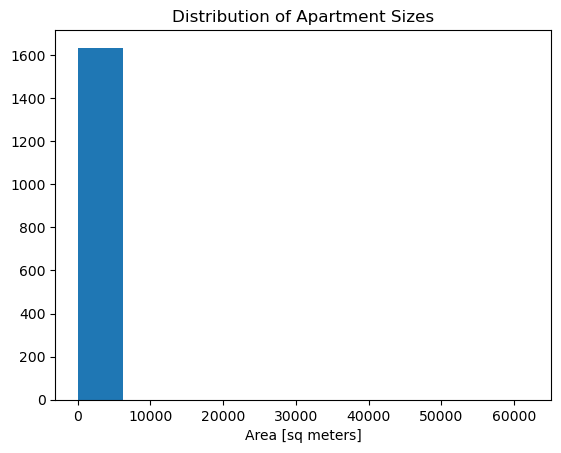

In [6]:
plt.hist(df["surface_covered_in_m2"]);
plt.xlabel("Area [sq meters]")
plt.title("Distribution of Apartment Sizes")

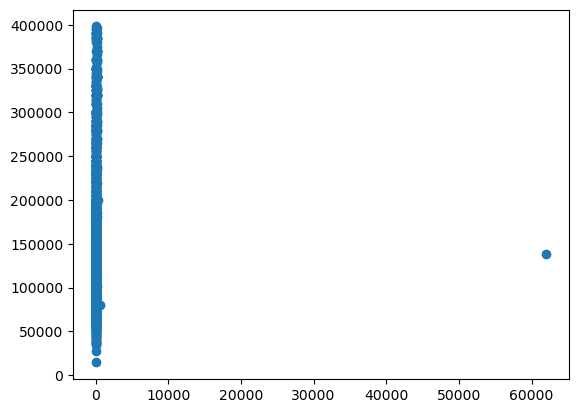

In [7]:
plt.scatter(df["surface_covered_in_m2"],df["price_aprox_usd"])

When you see a histogram like the one above, it suggests that there are outliers in your dataset. This can affect model performance — especially in the sorts of linear models we'll learn about in this project. To confirm, let's look at the summary statistics for the `"surface_covered_in_m2"` feature.

**Task 5:** Calculate the summary statistics for `df` using the [`describe`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.describe.html) method. 

In [8]:
df["surface_covered_in_m2"].describe()

count     1635.000000
mean        97.877064
std       1533.057610
min          0.000000
25%         38.000000
50%         50.000000
75%         73.000000
max      62034.000000
Name: surface_covered_in_m2, dtype: float64

The statistics above confirm what we suspected. While most of the apartments in our dataset are smaller that 73 square meters, there are some that are several thousand square meters. The best thing to do is to change our `wrangle` function and remove them from the dataset. 

**Task 6:** Add to your wrangle function so that it removes observations that are outliers in the `"surface_covered_in_m2"` column. Specifically, all observations should fall between the `0.1` and `0.9` quantiles for `"surface_covered_in_m2"`.

In [9]:
# === Redefining 'wrangle' to remove outliers
def wrangle(filepath):
    df = pd.read_csv(filepath)
    
    #Mask by "property_type"
    mask_apt = df["property_type"] == "apartment"
    #Mask by "Capital Federal"
    mask_place = df["place_with_parent_names"].str.contains("Capital Federal")
    #Mask by "price_aprox_usd"
    mask_price = df["price_aprox_usd"] < 400_000

    df = df[mask_apt & mask_place & mask_price]

    # Removing outliers by quantile method
    low, high = df["surface_covered_in_m2"].quantile([.1, .9])
    df = df[df["surface_covered_in_m2"].between(low, high)]
    
    return df

In [10]:
df = wrangle("buenos-aires-real-estate-1.csv")
print("df shape:", df.shape)
df.head()

df shape: (1343, 16)


,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
4,sell,apartment,|Argentina|Capital Federal|Chacarita|,"-34.5846508988,-58.4546932614",129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...
9,sell,apartment,|Argentina|Capital Federal|Villa Luro|,"-34.6389789,-58.500115",87000.0,USD,1319128.8,87000.0,48.0,42.0,1812.500000,2071.428571,NaN,NaN,NaN,http://villa-luro.properati.com.ar/12m82_venta...
29,sell,apartment,|Argentina|Capital Federal|Caballito|,"-34.615847,-58.459957",118000.0,USD,1789163.2,118000.0,NaN,54.0,NaN,2185.185185,NaN,2.0,NaN,http://caballito.properati.com.ar/11wqh_venta_...
40,sell,apartment,|Argentina|Capital Federal|Constitución|,"-34.6252219,-58.3823825",57000.0,USD,864256.8,57000.0,42.0,42.0,1357.142857,1357.142857,5.0,2.0,364.0,http://constitucion.properati.com.ar/k2f0_vent...
41,sell,apartment,|Argentina|Capital Federal|Once|,"-34.6106102,-58.4125107",90000.0,USD,1364616.0,90000.0,57.0,50.0,1578.947368,1800.000000,NaN,3.0,450.0,http://once.properati.com.ar/suwa_venta_depart...


Now that our dataset is free of outliers, it's time to start exploring the relationship between apartment size and price. Let's use one of the tools we learned in the last project.

**Task 7.1:** Create a scatter plot that shows price (`"price_aprox_usd"`) vs area (`"surface_covered_in_m2"`) in our dataset. Make sure to label your x-axis `"Area [sq meters]"` and your y-axis `"Price [USD]"`.

Text(0.5, 1.0, 'Buenos Aires: Price vs Area')

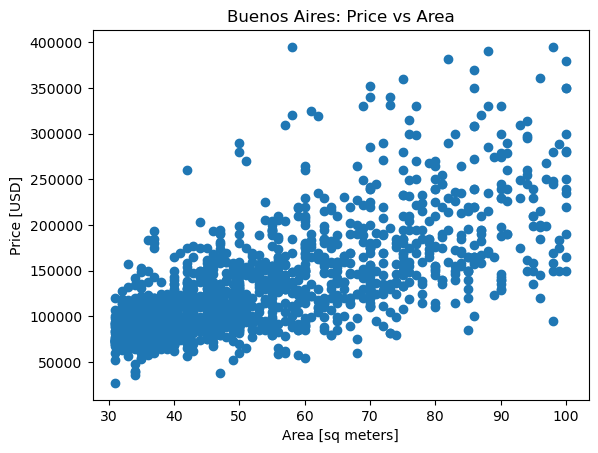

In [11]:
plt.scatter(df["surface_covered_in_m2"], df["price_aprox_usd"]);
plt.xlabel("Area [sq meters]")
plt.ylabel("Price [USD]")
plt.title("Buenos Aires: Price vs Area")

This plot suggests that there's a moderate positive correlation between apartment price and size. This means that if  thing we want to predict is price, size will be a good feature to include.  
We can as well measure this relationship by finding the correlation coefficient.

**Task 7.2:** Find the correlation coefficient between the ....

### **Split**

A key part in any model-building project is separating your **target** (the thing you want to predict) from your **features** (the information your model will use to make its predictions). Since this is our first model, we'll use just one feature: apartment size.

**Task 8:** Create the feature matrix named `X_train`, which you'll use to train your model. It should contain one feature only: `["surface_covered_in_m2"]`. Remember that your feature matrix should always be two-dimensional. 

In [12]:
features = ["surface_covered_in_m2"]
X_train = df[features]

Now that we have a features, the next step is to create a target. (By the way, you may have noticed that we're adding a `_train` tag to the variable names for our feature matrix and target vector. This is to remind us that this is the data we'll use to *train* our model, and not the data we'll use to *test* it.)

**Task 9:** Create the target vector named `y_train`, which you'll use to train your model. Your target should be `"price_aprox_usd"`. Remember that, in most cases, your target vector should be one-dimensional.

In [13]:
target = "price_aprox_usd"
y_train = df[target]

## **Build Model**

### Baseline

The first step in building a model is baselining. To do this, ask yourself how you will know if the model you build is performing well?" One way to think about this is to see how a "dumb" model would perform on the same data. Some people also call this a naïve or baseline model, but it's always a model makes only one prediction — in this case, it predicts the same price regardless of an apartment's size. So let's start by figuring out what our baseline model's prediction should be. 

**Task 10:** Calculate the mean of your target vector `y_train` and assign it to the variable `y_mean`.

In [14]:
y_mean = df["price_aprox_usd"].mean()
y_mean

np.float64(135527.83871928515)

Now that we have the one prediction that our dumb model will always make, we need to generate a list that repeats the prediction for every observation in our dataset. 

**Task 11:** Create a list named `y_pred_baseline` that contains the value of `y_mean` repeated so that it's the same length at `y`.

In [15]:
y_pred_baseline = [y_mean]*len(y_train)
len(y_pred_baseline)

1343

So how does our baseline model perform? One way to evaluate it is by plotting it on top of the scatter plot we made above. 

**Task 12:** Add a line to the plot below that shows the relationship between the observations `X_train` and our dumb model's predictions `y_pred_baseline`. Be sure that the line color is orange, and that it has the label `"Baseline Model"`.

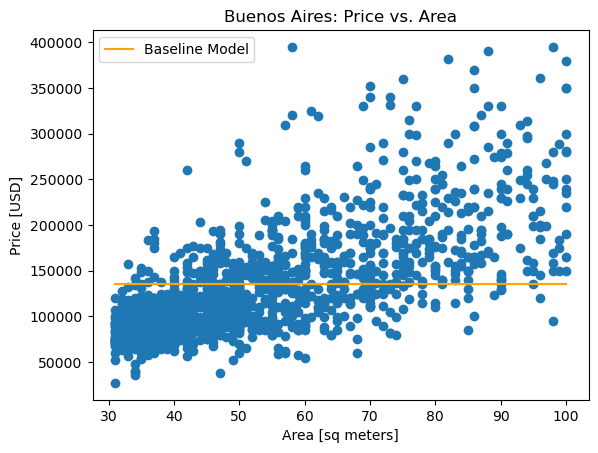

In [16]:
# Add a line to the plot
plt.plot(X_train, y_pred_baseline, color="orange", label="Baseline Model")

plt.scatter(X_train, y_train)
plt.xlabel("Area [sq meters]")
plt.ylabel("Price [USD]")
plt.title("Buenos Aires: Price vs. Area")
plt.legend();

Looking at this visualization, it seems like our baseline model doesn't really follow the trend in the data. But, as a data scientist, you can't depend only on a subjective plot to evaluate a model. You need an exact, mathematically calculated **performance metric**. There are lots of performance metrics, but the one we'll use here is the **mean absolute error**.  

**Task 13:** Calculate the baseline mean absolute error for your predictions in `y_pred_baseline` as compared to the true targets in `y`.

In [17]:
mae_baseline = mean_absolute_error(y_train, y_pred_baseline)

print("Mean apt price", round(y_mean, 2))
print("Baseline MAE:", round(mae_baseline, 2))

Mean apt price 135527.84
Baseline MAE: 45199.46


What does this information tell us? If we always predicted that an apartment price is \\$135,527.84, our predictions would be off by an average of \\$45,199.46. It also tells us that our model needs to have mean absolute error below \\$45,199.46 in order to be useful.

### Iterate

The next step in building a model is iterating. This involves building a model, training it, evaluating it, and then repeating the process until you're happy with the model's performance. 

The first thing we need to do is create our model — in this case, one that uses linear regression.

**Task 14:** Instantiate a [`LinearRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) model named `model`.

In [18]:
model = LinearRegression()

The second thing we need to do is use our data to train our model. Another way to say this is fit our model to the training data. 

**Task 15:** Fit your model to the data, `X_train` and `y_train`.

In [19]:
model.fit(X_train, y_train)

LinearRegression()

### **Evaluate**

The final step is to evaluate our model. In order to do that, we'll start by seeing how well it performs when making predictions for data that it saw during training. So let's have it predict the price for the houses in our training set.

**Task 16:** Using your model's [`predict`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression.predict) method, create a list of predictions for the observations in your feature matrix `X_train`. Name this array `y_pred_training`. 

In [20]:
y_pred_training = model.predict(X_train)
y_pred_training[:5]

array([169151.87330223, 106064.44707446, 133101.91545779, 106064.44707446,
       124089.42599668])

Now that we have predictions, we'll use them to assess our model's performance with the training data. We'll use the same metric we used to evaluate our baseline model: mean absolute error. 

**Task 17:** Calculate your training mean absolute error for your predictions in `y_pred_training` as compared to the true targets in `y_train`.

In [21]:
mae_training = mean_absolute_error(y_train, y_pred_training)
print("Training MAE:", round(mae_training, 2))

Training MAE: 31248.26


Our model beat the baseline by over \$10,000! That's a good indicator that it will be helpful in predicting apartment prices. But the real test is how the model performs on data that it hasn't seen before, data that we call the **test set**. In the future, you'll create your own test set before you train your model, but here we'll use one that's pre-made

**Task 18:** Run the code below to import your test data `buenos-aires-test-features.csv` into a DataFrame and generate a Series of predictions using your model.  After the code runs successfully, click the **Check Activity** button on the left pane to verify your predictions.

Once your model is built and tested, it's time to share it with others. If you're presenting to simple linear model to a technical audience, they might appreciate an equation. When we created our baseline model, we represented it as a line. The equation for a line like this is usually written as:

<center>y = m*x + b</center>

**Task 19:** Extract the intercept from your model, and assign it to the variable `intercept`.

In [22]:
intercept = round(model.intercept_, 2)
print("Model Intercept:", intercept)

Model Intercept: 11433.31


**Task 20:** Extract the coefficient associated `"surface_covered_in_m2"` in your model, and assign it to the variable `coefficient`.

Now that we have our `intercept` and `coefficient`, we need to insert them into a string that we can print out the complete equation.

In [27]:
coefficient = round(model.coef_[0], 2)

**Task 21:** Complete the code below and run the cell to print the equation that your model has determined for predicting apartment price based on size.

In [28]:
print(f"apartment_price = {intercept} + {coefficient} * surface_covered") 

apartment_price = 11433.31 + 2253.12 * surface_covered


**Task 22:** Add a line to the plot below that shows the relationship between the observations in `X_train` and your model's predictions `y_pred_training`. Be sure that the line color is red, and that it has the label `"Linear Model"`.

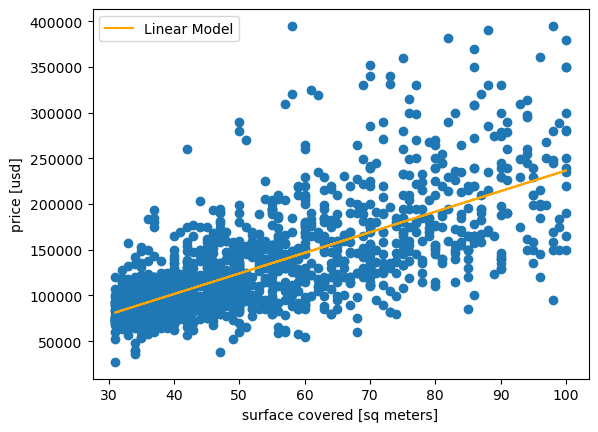

In [24]:
# Add a line to the plot
plt.plot(X_train, y_pred_training, color="orange", label="Linear Model")

plt.scatter(X_train, y_train)
plt.xlabel("surface covered [sq meters]")
plt.ylabel("price [usd]")
plt.legend();

In [36]:
import numpy as np

def rmse(predictions, targets):
    # Convert lists to numpy arrays first
    predictions = np.array(predictions)
    targets = np.array(targets)
    return np.sqrt(np.mean((predictions - targets)**2))

y = [2, 4, 6, 8]
x = [5, 5, 5, 5]

print(rmse(y, x))


2.23606797749979
